# **Machine Learning Models**

1. Logistic Regression
2. Random Forest
3. XGBoost

### **1.Logistic Regression**

In [37]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.linear_model import LogisticRegression

In [38]:
df = pd.read_csv('cleaned_telco_churn_predictive.csv')

Step 1: Test train split (80/20)

test training - stratification applied so there is equal proportion of churners and non-churners in test and training set as our actual data


In [39]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Paperless Billing,Monthly Charges,Churn Value,Multiple Lines_Yes,...,Online Backup_Yes,Device Protection_Yes,Tech Support_Yes,Streaming TV_Yes,Streaming Movies_Yes,Contract_One year,Contract_Two year,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,1,0,0,0,2,1,1,53.85,1,0,...,1,0,0,0,0,0,0,0,0,1
1,0,0,0,1,2,1,1,70.70,1,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,1,8,1,1,99.65,1,1,...,0,1,0,1,1,0,0,0,1,0
3,0,0,1,1,28,1,1,104.80,1,1,...,0,1,1,1,1,0,0,0,1,0
4,1,0,0,1,49,1,1,103.70,1,1,...,1,1,0,1,1,0,0,0,0,0


In [40]:
from sklearn.model_selection import train_test_split

# 1. Separate your features (X) from your target variable (y)
# We drop 'Churn Value' because it is the answer we want to predict.
# We drop 'CustomerID' because random ID strings confuse machine learning models.
X = df.drop(columns=['Churn Value', 'CustomerID'], errors='ignore')

y = df['Churn Value']

# 2. Perform the 80/20 split
# test_size=0.20 sets 20% of data for testing and 80% for training
# random_state=42 locks the random seed so your results are reproducible every time
# stratify=y guarantees the same ratio of 1s and 0s in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 3. Verify the split sizes
print(f"Training data: {X_train.shape[0]} customers")
print(f"Testing data: {X_test.shape[0]} customers")

Training data: 5634 customers
Testing data: 1409 customers


Step 2: Applying Feature scaling : to make our variables on the same metric (Feature scaling applied only to logistic models)

In [41]:
# 1. Initialize the standard scaler
scaler = StandardScaler()

# 2. Fit on training data AND transform it
# We wrap it in pd.DataFrame to keep your column names attached (crucial for feature importance later)
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

# 3. ONLY transform the testing data (do NOT fit again)
# This applies the exact same mathematical rules learned from the training data
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# 4. Preview the newly scaled training data to verify it worked
X_train_scaled.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Paperless Billing,Monthly Charges,Multiple Lines_Yes,Internet Service_Fiber optic,...,Online Backup_Yes,Device Protection_Yes,Tech Support_Yes,Streaming TV_Yes,Streaming Movies_Yes,Contract_One year,Contract_Two year,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
4626,0.994336,-0.441773,-0.969234,-0.547954,0.102371,-3.013090,-1.202653,-0.521976,-0.858338,-0.887696,...,-0.735546,1.375572,-0.643274,1.252163,1.247967,-0.512782,-0.563822,-0.523806,1.406903,-0.543846
4192,0.994336,-0.441773,1.031742,1.824970,-0.711743,0.331885,-1.202653,0.337478,-0.858338,1.126512,...,-0.735546,-0.726971,-0.643274,-0.798618,-0.801303,-0.512782,-0.563822,-0.523806,-0.710781,1.838757
5457,0.994336,-0.441773,1.031742,1.824970,-0.793155,-3.013090,-1.202653,-0.809013,-0.858338,-0.887696,...,1.359534,-0.726971,1.554547,-0.798618,-0.801303,-0.512782,1.773611,-0.523806,-0.710781,1.838757
4717,-1.005696,-0.441773,1.031742,-0.547954,-0.263980,0.331885,0.831495,0.284384,-0.858338,-0.887696,...,1.359534,1.375572,-0.643274,1.252163,1.247967,-0.512782,1.773611,1.909105,-0.710781,-0.543846
4673,0.994336,-0.441773,1.031742,1.824970,-1.281624,0.331885,-1.202653,-0.676279,-0.858338,-0.887696,...,-0.735546,-0.726971,-0.643274,-0.798618,-0.801303,-0.512782,-0.563822,-0.523806,1.406903,-0.543846


Step 3: Feature selection (using L1/L2 method ), fitting on training and predict on test

In [42]:
 #1. Initialize the model with Elastic Net (combines L1 and L2)
# solver='saga' is the specific algorithm required to use elasticnet in scikit-learn
# l1_ratio=0.5 applies a perfect 50/50 split between L1 (dropping) and L2 (shrinking)
# class_weight='balanced' automatically adjusts for the fact that you have fewer churners than safe customers
# max_iter=2000 gives the mathematical equations enough time to finish converging
log_model = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.5,
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)

# 2. Train the model using ONLY your scaled training data
log_model.fit(X_train_scaled, y_train)

# 3. Generate exact predictions on the test data (1 = Churn, 0 = Safe)
y_pred = log_model.predict(X_test_scaled)

# 4. Generate probability scores (the exact % chance a customer will churn)
# predict_proba generates two columns (prob of 0, prob of 1). [:, 1] grabs just the probability of 1.
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

print("Model successfully trained and test predictions generated!")

c:\Users\Meklit\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Model successfully trained and test predictions generated!


In [43]:
# 1. Get the baseline intercept (often called X0 or Bias)
intercept = log_model.intercept_[0]

# 2. Get the list of feature names and their corresponding coefficients
feature_names = X_train_scaled.columns
coefficients = log_model.coef_[0]

# 3. Start building the visual equation string with the intercept
equation = f"{intercept:.4f}"

print("--- Features Selected by L1/L2 (Non-Zero Coefficients) ---")

# 4. Loop through every feature to see what the model kept
for name, coef in zip(feature_names, coefficients):

    # If the coefficient is exactly 0, the L1 penalty dropped it.
    # We only want to keep and print features where the coefficient is NOT zero.
    if coef != 0:
        print(f"{name}: {coef:.4f}")

        # Add the selected feature to our equation string, handling plus/minus signs cleanly
        if coef > 0:
            equation += f" + {coef:.4f}*{name}"
        else:
            equation += f" - {abs(coef):.4f}*{name}"

print("\n--- Final Logistic Regression Equation ---")
print(equation)

--- Features Selected by L1/L2 (Non-Zero Coefficients) ---
Gender: 0.0161
Senior Citizen: 0.0092
Partner: 0.1363
Dependents: -0.6899
Tenure Months: -0.7879
Phone Service: -0.0250
Paperless Billing: 0.1549
Monthly Charges: -0.5054
Multiple Lines_Yes: 0.1875
Internet Service_Fiber optic: 0.6188
Internet Service_No: -0.4864
Online Security_Yes: -0.1208
Online Backup_Yes: -0.0035
Device Protection_Yes: 0.0309
Tech Support_Yes: -0.1031
Streaming TV_Yes: 0.2162
Streaming Movies_Yes: 0.2253
Contract_One year: -0.3237
Contract_Two year: -0.6045
Payment Method_Credit card (automatic): -0.0058
Payment Method_Electronic check: 0.1852
Payment Method_Mailed check: 0.0294

--- Final Logistic Regression Equation ---
-0.7203 + 0.0161*Gender + 0.0092*Senior Citizen + 0.1363*Partner - 0.6899*Dependents - 0.7879*Tenure Months - 0.0250*Phone Service + 0.1549*Paperless Billing - 0.5054*Monthly Charges + 0.1875*Multiple Lines_Yes + 0.6188*Internet Service_Fiber optic - 0.4864*Internet Service_No - 0.1208*On

Step 4: Metrics Evaluation

--- Logistic Regression Metrics ---
Accuracy:  0.7431
Precision: 0.5108
Recall:    0.7620
F1 Score:  0.6116
ROC-AUC:   0.8463



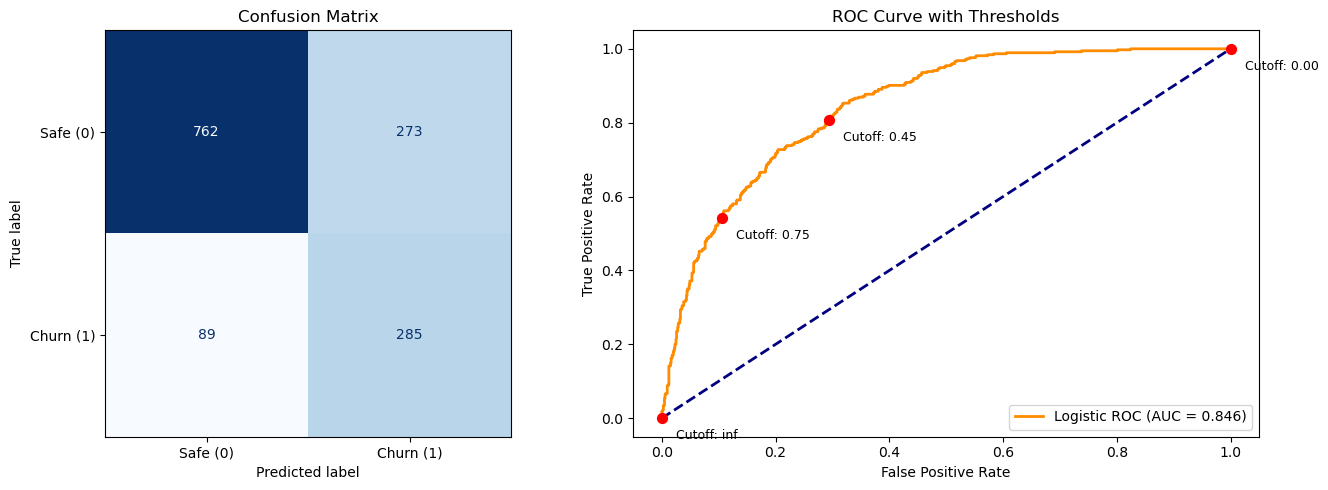

In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate all the required metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("--- Logistic Regression Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}\n")

# 2. Set up a side-by-side visual display
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 3. Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe (0)', 'Churn (1)'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')

# 4. Plot the ROC Curve
# Plot the base ROC curve and the 50/50 line
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Logistic ROC (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# --- NEW CODE: ADDING THRESHOLD MARKERS ---
# Automatically select 4 evenly spaced indices from the arrays
demo_indices = np.linspace(0, len(thresholds) - 1, 4).astype(int)

for i in demo_indices:
    # Plot a red dot at the specific FPR and TPR
    axes[1].scatter(fpr[i], tpr[i], color='red', s=50, zorder=5)

    # Add a text label showing the exact threshold value
    # xytext=(10, -15) shifts the text slightly down and to the right so it doesn't overlap the dot
    axes[1].annotate(f'Cutoff: {thresholds[i]:.2f}',
                     (fpr[i], tpr[i]),
                     textcoords="offset points",
                     xytext=(10, -15),
                     ha='left',
                     fontsize=9,
                     color='black')
# ------------------------------------------

axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve with Thresholds')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

### **2.Random Forest**

Step 1: train -test- split

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# --- STEP 1: TRAIN-TEST SPLIT ---
X = df.drop(columns=['Churn Value', 'CustomerID'], errors='ignore')
y = df['Churn Value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

Step 2: Train and predict

In [46]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1. Define the grid of options to test
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15]
}

# 2. Initialize a blank base model
rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')

# 3. Set up Grid Search
# cv=5 means it cross-validates (double-checks) its work 5 times for accuracy
# scoring='f1' tells it to pick the winner based on the best F1 Score, not just base accuracy
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=5, scoring='f1')

# 4. Train the grid search (this may take a minute or two to test all combinations)
grid_search.fit(X_train, y_train)

# 5. Reveal the winning combination
print("Best parameters found:", grid_search.best_params_)

# 6. Automatically save the winning model to generate predictions
best_rf_model = grid_search.best_estimator_

# Generate new predictions using the absolute best version of your model
y_pred_best_rf = best_rf_model.predict(X_test)
y_prob_best_rf = best_rf_model.predict_proba(X_test)[:, 1]

Best parameters found: {'max_depth': 10, 'n_estimators': 200}


Step 3:Key Metrics and Feature importance

--- Optimized Random Forest Metrics ---
Accuracy:  0.7637
Precision: 0.5380
Recall:    0.7754
F1 Score:  0.6353
ROC-AUC:   0.8508



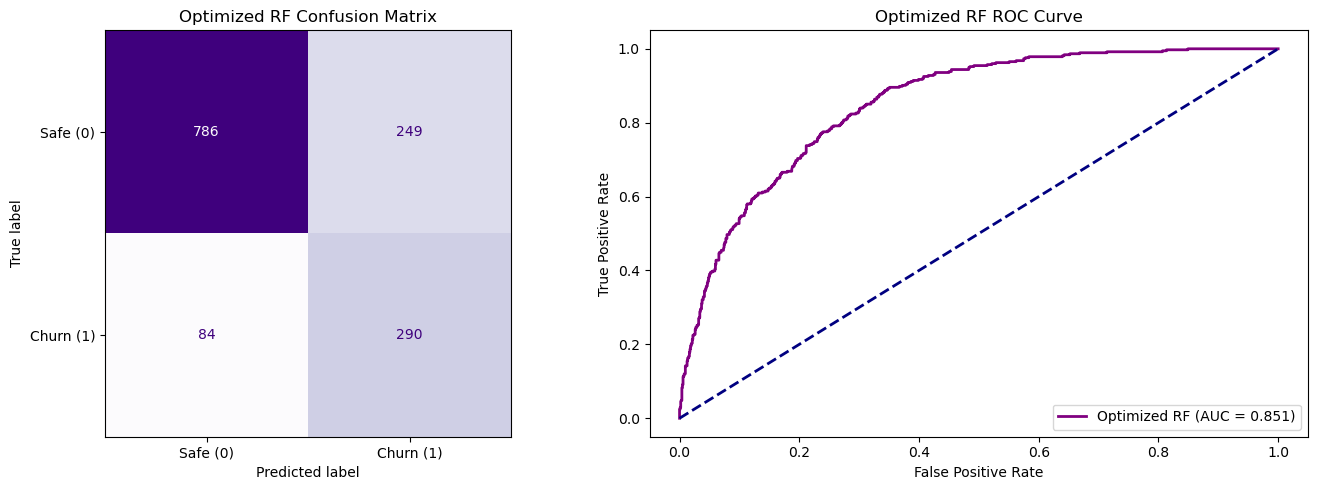

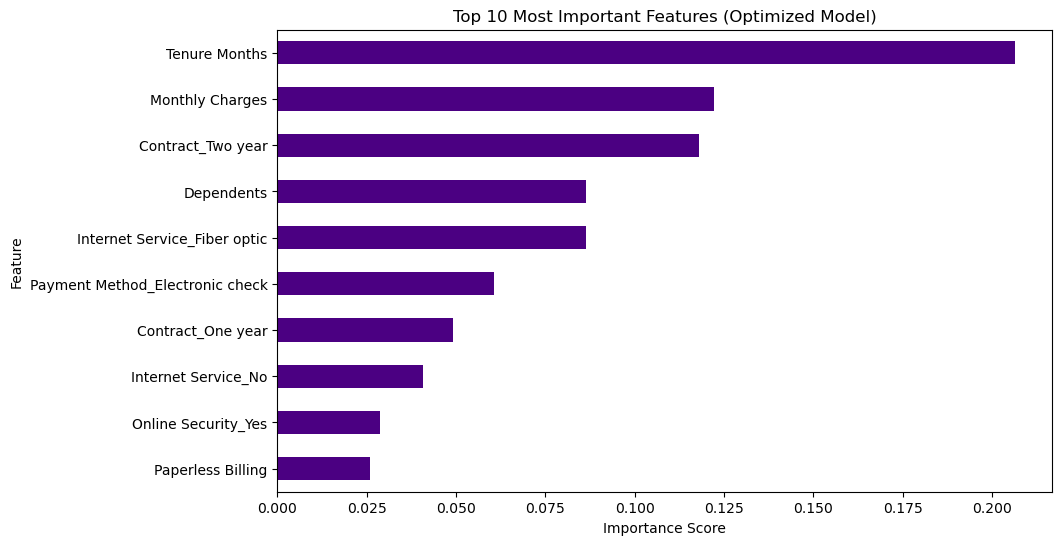

In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve
import matplotlib.pyplot as plt
import pandas as pd

# 1. Calculate metrics using your OPTIMIZED RF predictions
accuracy_best = accuracy_score(y_test, y_pred_best_rf)
precision_best = precision_score(y_test, y_pred_best_rf)
recall_best = recall_score(y_test, y_pred_best_rf)
f1_best = f1_score(y_test, y_pred_best_rf)
roc_auc_best = roc_auc_score(y_test, y_prob_best_rf)

print("--- Optimized Random Forest Metrics ---")
print(f"Accuracy:  {accuracy_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall:    {recall_best:.4f}")
print(f"F1 Score:  {f1_best:.4f}")
print(f"ROC-AUC:   {roc_auc_best:.4f}\n")

# 2. Plot Confusion Matrix and ROC Curve side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix (Using purple to distinguish from your baseline)
cm_best = confusion_matrix(y_test, y_pred_best_rf)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=['Safe (0)', 'Churn (1)'])
disp_best.plot(ax=axes[0], cmap='Purples', colorbar=False)
axes[0].set_title('Optimized RF Confusion Matrix')

# ROC Curve
fpr_best, tpr_best, _ = roc_curve(y_test, y_prob_best_rf)
axes[1].plot(fpr_best, tpr_best, color='purple', lw=2, label=f'Optimized RF (AUC = {roc_auc_best:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Optimized RF ROC Curve')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# 3. Extract and Plot Feature Importance from the BEST model
feature_importances_best = pd.Series(best_rf_model.feature_importances_, index=X_train.columns)
top_10_features_best = feature_importances_best.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_10_features_best.sort_values(ascending=True).plot(kind='barh', color='indigo')
plt.title('Top 10 Most Important Features (Optimized Model)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

Step 4: SHAP: for direction of the metrics

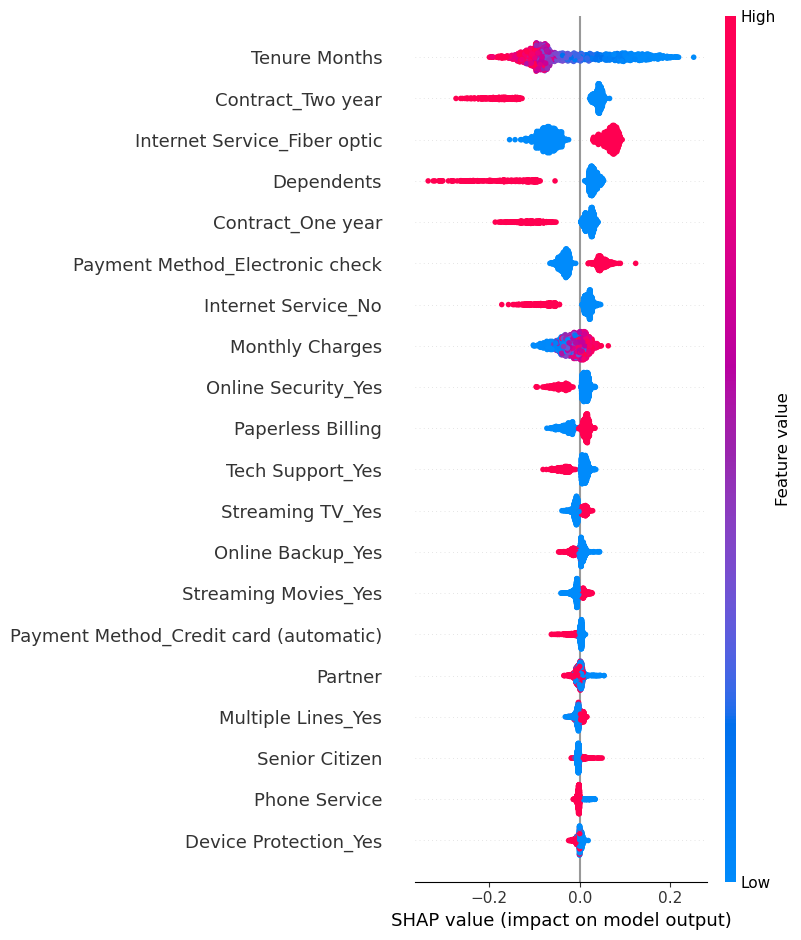

In [48]:
import shap

# 1. Initialize the SHAP explainer
explainer = shap.TreeExplainer(best_rf_model)

# 2. Calculate the exact math
shap_values = explainer.shap_values(X_test)

# 3. Extract the correct slice of data for the "Churn" group based on the new SHAP format
# If SHAP returned a 3D array (New format)
if len(np.shape(shap_values)) == 3:
    shap_values_churn = shap_values[:, :, 1]
# If SHAP returned a list (Old format fallback just in case)
else:
    shap_values_churn = shap_values[1]

# 4. Generate the visual Summary Plot
shap.summary_plot(shap_values_churn, X_test)

#### **3.XGBOOST**

In [ ]:
#!pip install xgboost

In [51]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve
import matplotlib.pyplot as plt

Step 1: Setting Parameters such such as learning rate, weight , tree depth and number of trees

In [ ]:
# 1. Calculate the exact weight needed for imbalanced data (Total Safe / Total Churned)
weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

In [53]:
# 2. Initialize the XGBoost model
# learning_rate (often called 'eta') controls how aggressively it corrects past mistakes
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=weight,
    random_state=42
)

Step 2: Training and prediction

In [54]:
# 3. Train the model on your unscaled data
xgb_model.fit(X_train, y_train)

# 4. Generate predictions and probability scores
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

Step 3: Metric Evaluation 

--- XGBoost Metrics ---
Accuracy:  0.7530
Precision: 0.5229
Recall:    0.7941
F1 Score:  0.6306
ROC-AUC:   0.8517



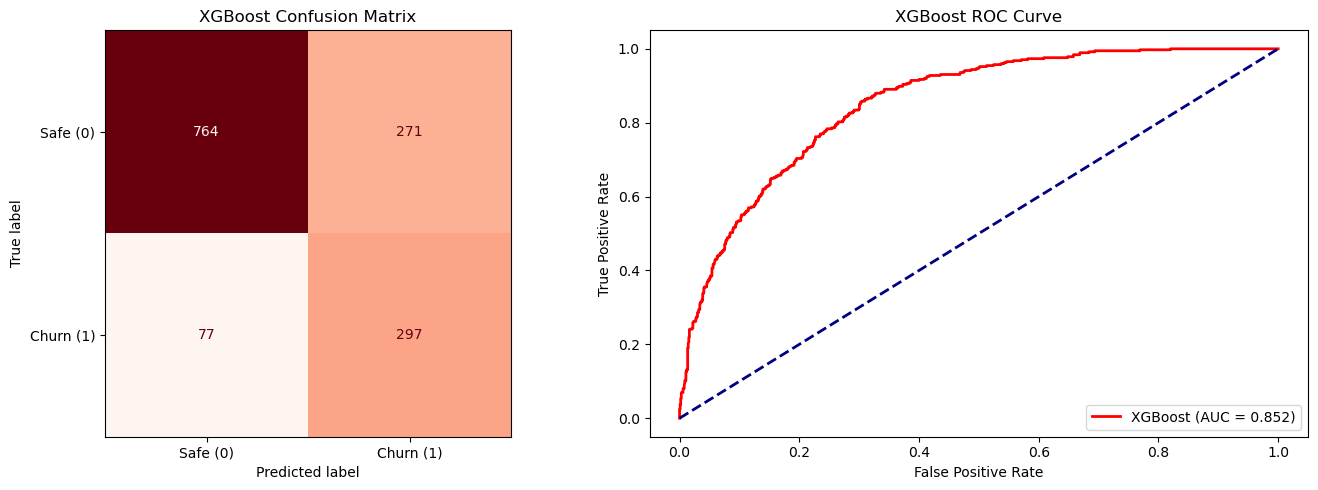

In [55]:
# --- 5. EVALUATION AND VISUALIZATION ---
print("--- XGBoost Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_xgb):.4f}\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix (Using reds to distinguish from your other models)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Safe (0)', 'Churn (1)'])
disp_xgb.plot(ax=axes[0], cmap='Reds', colorbar=False)
axes[0].set_title('XGBoost Confusion Matrix')

# ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
axes[1].plot(fpr_xgb, tpr_xgb, color='red', lw=2, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('XGBoost ROC Curve')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

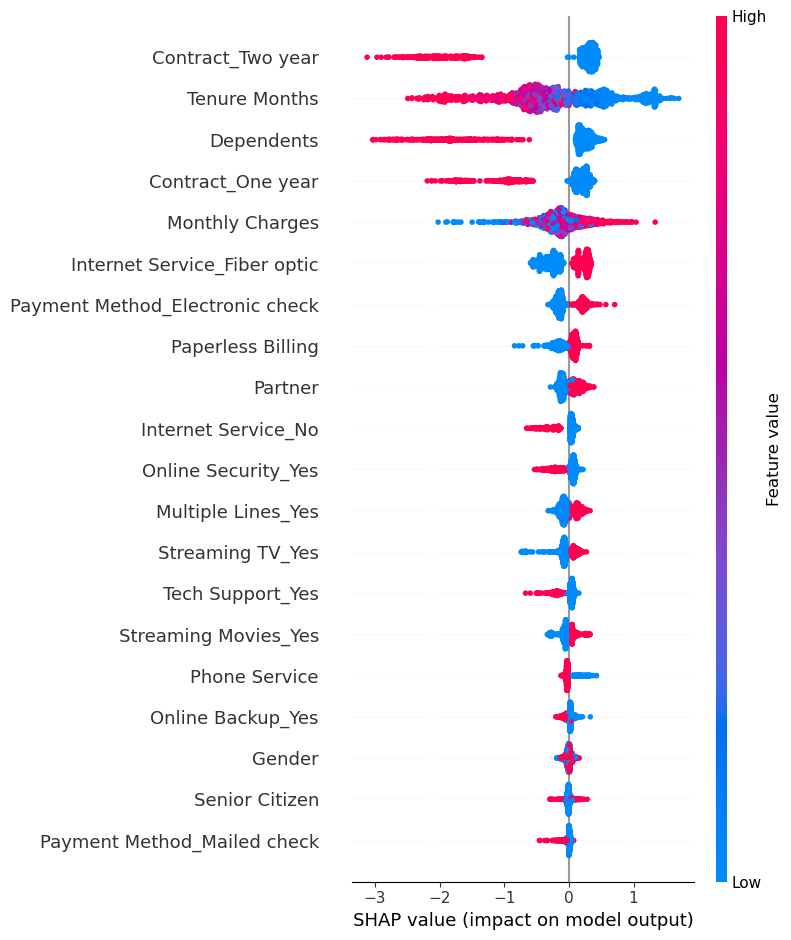

In [56]:
import shap
import numpy as np

# 1. Initialize the SHAP explainer specifically for your new XGBoost model
explainer_xgb = shap.TreeExplainer(xgb_model)

# 2. Calculate the exact math for your test data
shap_values_xgb = explainer_xgb.shap_values(X_test)

# 3. Extract the correct slice of data safely
if isinstance(shap_values_xgb, list):
    shap_data = shap_values_xgb[1]
elif len(np.shape(shap_values_xgb)) == 3:
    shap_data = shap_values_xgb[:, :, 1]
else:
    # XGBoost usually outputs a clean 2D array by default, which needs no slicing
    shap_data = shap_values_xgb

# 4. Generate the visual Summary Plot
shap.summary_plot(shap_data, X_test)

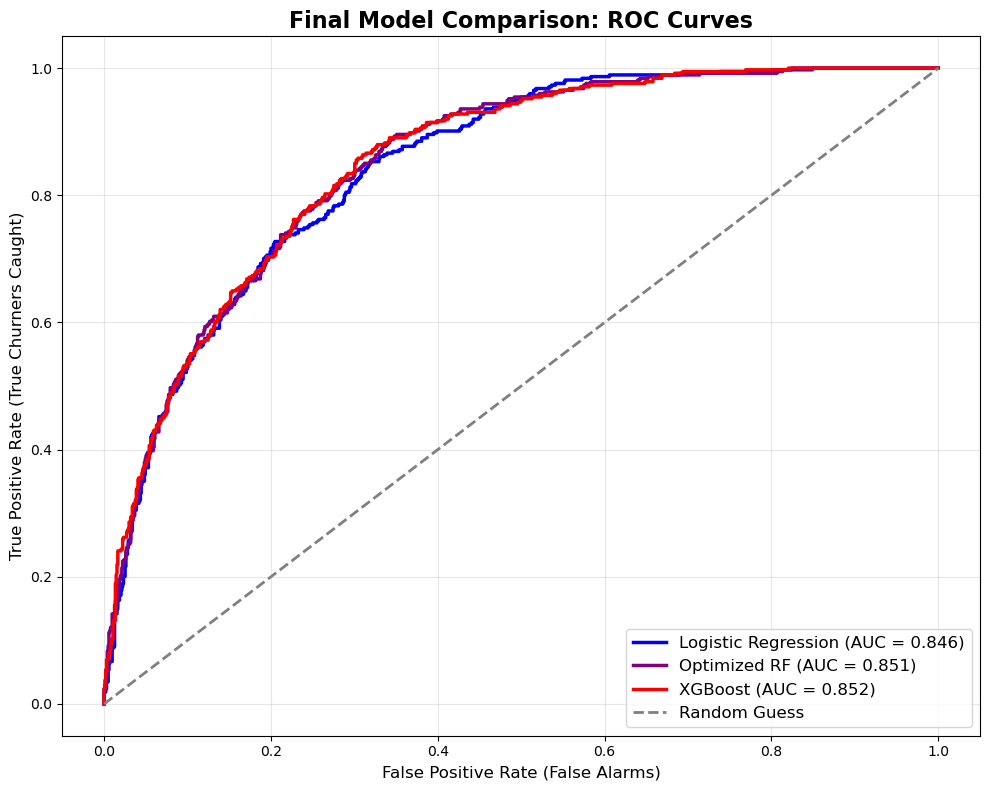

In [57]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Set up the chart size
plt.figure(figsize=(10, 8))

# 1. Logistic Regression Curve (Corrected to use 'y_prob')
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
auc_lr = roc_auc_score(y_test, y_prob)
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2.5, label=f'Logistic Regression (AUC = {auc_lr:.3f})')

# 2. Optimized Random Forest Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_best_rf)
auc_rf = roc_auc_score(y_test, y_prob_best_rf)
plt.plot(fpr_rf, tpr_rf, color='purple', lw=2.5, label=f'Optimized RF (AUC = {auc_rf:.3f})')

# 3. XGBoost Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
plt.plot(fpr_xgb, tpr_xgb, color='red', lw=2.5, label=f'XGBoost (AUC = {auc_xgb:.3f})')

# 4. The Baseline (Random Guessing)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess')

# Format the chart for a presentation
plt.xlabel('False Positive Rate (False Alarms)', fontsize=12)
plt.ylabel('True Positive Rate (True Churners Caught)', fontsize=12)
plt.title('Final Model Comparison: ROC Curves', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Model Comparision Summary shows XGBOOST as top performer followed by Random Forest and Logistic Regression in ROC- AUC score 

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|---------|---------:|----------:|--------:|---------:|--------:|
| Logistic Regression | 0.7431 | 0.5108 | 0.7620 | 0.6116 | 0.8463 |
| Random Forest (Optimized) | 0.7637 | 0.5380 | 0.7754 | 0.6353 | 0.8508 |
| XGBoost | 0.7530 | 0.5229 | 0.7941 | 0.6306 | 0.8517 |


**Key observations:**
- Random Forest achieved the highest Accuracy (0.7637) and F1 Score (0.6353).
- XGBoost achieved the highest Recall (0.7941) and ROC-AUC (0.8517), making it the strongest model for identifying churners.
- Logistic Regression performed competitively despite its simplicity, but trailed the tree-based models across all metrics.